# Taller B3-T4 ? Redes Neuronales para Forecasting
## Ventana entrada: 10 dias
## Ventana salida: 90 dias

- **Parte 1 ? Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 ? Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 10   # dias de entrada
VENTANA_SALIDA  = 90   # dias de salida (promedio)


In [2]:
import sys
sys.path.insert(0, '..')
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import (
    construir_dense, construir_dense_v2, construir_dense_v3,
    construir_dense_v4, construir_dense_v5, construir_dense_v6,
    construir_recurrente, construir_conv1d, construir_mixto
)
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
import utilidades.modelos as modelos_mod
import utilidades.tuning as tuning_mod
from utilidades.tuning import plot_best_history


def crear_callbacks_base(patience=18, rlr_patience=6, min_delta=1e-6, min_lr=1e-7):
    return [
        EarlyStopping(
            monitor='val_loss', patience=patience, min_delta=min_delta,
            restore_best_weights=True, mode='min', verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=rlr_patience,
            min_delta=min_delta, min_lr=min_lr, mode='min', verbose=1,
        ),
    ]

CALLBACKS = crear_callbacks_base()


def registrar_modelos_parametricos():
    def construir_lstm_param(
        forma_entrada,
        dim_salida,
        units=24,
        dropout=0.30,
        recurrent_dropout=0.0,
        l2=1e-4,
    ):
        reg = modelos_mod.regularizers.l2(l2) if l2 and l2 > 0 else None
        modelo = modelos_mod.Sequential(name='LSTM_param')
        modelo.add(modelos_mod.LSTM(
            units=units,
            input_shape=forma_entrada,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
            return_sequences=False,
        ))
        modelo.add(modelos_mod.Dense(dim_salida, kernel_regularizer=reg))
        modelo.compile(optimizer='adam', loss='mae')
        return modelo

    def construir_conv1d_param(
        forma_entrada,
        dim_salida,
        filtros=24,
        kernel=3,
        dropout=0.35,
        l2=1e-4,
    ):
        reg = modelos_mod.regularizers.l2(l2) if l2 and l2 > 0 else None
        modelo = modelos_mod.Sequential(name='Conv1D_param')
        modelo.add(modelos_mod.Conv1D(
            filtros, kernel_size=kernel, activation='relu', padding='same',
            kernel_regularizer=reg, input_shape=forma_entrada,
        ))
        modelo.add(modelos_mod.Conv1D(
            max(8, filtros // 2), kernel_size=kernel, activation='relu',
            padding='same', kernel_regularizer=reg,
        ))
        modelo.add(modelos_mod.GlobalAveragePooling1D())
        modelo.add(modelos_mod.Dropout(dropout))
        modelo.add(modelos_mod.Dense(dim_salida, kernel_regularizer=reg))
        modelo.compile(optimizer='adam', loss='mae')
        return modelo

    def construir_mixto_param(
        forma_entrada,
        dim_salida,
        filtros=24,
        lstm_units=16,
        kernel=3,
        dropout=0.35,
        l2=1e-4,
    ):
        reg = modelos_mod.regularizers.l2(l2) if l2 and l2 > 0 else None
        entradas = modelos_mod.Input(shape=forma_entrada)
        x = modelos_mod.Conv1D(
            filtros, kernel_size=kernel, activation='relu', padding='same',
            kernel_regularizer=reg,
        )(entradas)
        x = modelos_mod.Dropout(dropout)(x)
        x = modelos_mod.LSTM(
            lstm_units,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            bias_regularizer=reg,
        )(x)
        x = modelos_mod.Dropout(dropout)(x)
        salidas = modelos_mod.Dense(dim_salida, kernel_regularizer=reg)(x)
        modelo = modelos_mod.Model(inputs=entradas, outputs=salidas, name='Mixto_param')
        modelo.compile(optimizer='adam', loss='mae')
        return modelo

    for nombre, fn in {
        'construir_lstm_param': construir_lstm_param,
        'construir_conv1d_param': construir_conv1d_param,
        'construir_mixto_param': construir_mixto_param,
    }.items():
        setattr(modelos_mod, nombre, fn)
        setattr(tuning_mod, nombre, fn)
        setattr(tuning_mod.modelos, nombre, fn)

registrar_modelos_parametricos()


def resultado_canonico(resultado, nombre):
    return {
        'modelo': nombre,
        'mae_train': float(resultado['mae_train']),
        'mae_val': float(resultado['mae_val']),
        'mae_test': float(resultado['mae_test']),
        'n_params': int(resultado['n_params']),
    }


def graficar_metricas_resultado(resultado, titulo):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.bar(
        ['Train', 'Validacion', 'Test'],
        [resultado['mae_train'], resultado['mae_val'], resultado['mae_test']],
        color=['steelblue', 'orange', 'tomato'],
    )
    ax.set_title(titulo)
    ax.set_ylabel('MAE')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def entrenar_candidatos_parametricos(
    model_fn_name,
    candidatos,
    base_cfg,
    X_train_model,
    y_train,
    X_val_model,
    y_val,
    X_eval_train,
    X_eval_val,
    X_eval_test,
):
    resultados = []
    historias = {}
    modelos_entrenados = {}
    total = len(candidatos)

    for i, candidato in enumerate(candidatos, start=1):
        cfg = {**base_cfg, **candidato}
        nombre = cfg.pop('nombre')
        print(f'Entrenando {nombre} ({i}/{total})...')
        score, best_val, best_epoch, best_train, best_gap, hist, model = tuning_mod._train_one(
            model_fn_name,
            cfg,
            X_train_model, y_train,
            X_val_model, y_val,
        )
        met = evaluar_modelo(
            model,
            X_eval_train, y_train,
            X_eval_val, y_val,
            X_eval_test, y_test,
            nombre=nombre,
        )
        met.update({
            'balanced_score': float(score),
            'best_val_loss': float(best_val),
            'best_train_eval_loss': float(best_train),
            'best_train_val_gap': float(best_gap),
            'best_epoch': int(best_epoch),
            'cfg': cfg,
        })
        resultados.append(met)
        historias[nombre] = hist
        modelos_entrenados[nombre] = model
        print({k: met[k] for k in ['mae_train', 'mae_val', 'mae_test', 'best_train_val_gap', 'best_epoch']})

    df = pd.DataFrame(resultados).sort_values(
        ['balanced_score', 'mae_val', 'mae_test']
    ).reset_index(drop=True)
    mejor_nombre = df.loc[0, 'modelo']
    return df, historias[mejor_nombre], modelos_entrenados[mejor_nombre], df.loc[0].to_dict()


def seleccionar_mejor_familia(resultados, nombre_final):
    filas = []
    for origen, resultado in resultados:
        fila = resultado_canonico(resultado, nombre_final)
        fila['origen'] = origen
        filas.append(fila)
    df = pd.DataFrame(filas).sort_values(['mae_val', 'mae_test', 'mae_train']).reset_index(drop=True)
    display(df[['origen', 'modelo', 'mae_train', 'mae_val', 'mae_test', 'n_params']].round(6))
    elegido = resultado_canonico(df.loc[0].to_dict(), nombre_final)
    print(f"Resultado activo para {nombre_final}: {df.loc[0, 'origen']}")
    return elegido, df


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [3]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16091, 10, 23)  |  y: (16091, 23)
Train: (13756, 10, 23)  Val: (725, 10, 23)  Test: (1610, 10, 23)


## 1.2 Baseline Lineal


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.001237,0.001003,0.001282,0


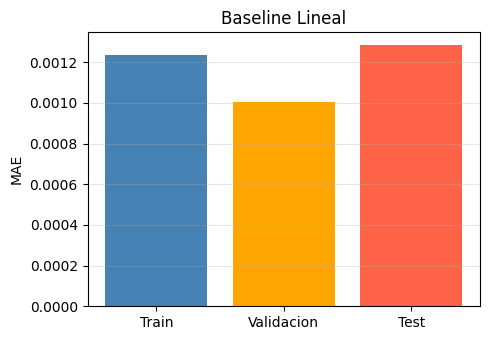

In [4]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')

display(pd.DataFrame([resultado_lineal]).set_index('modelo').round(6))
graficar_metricas_resultado(resultado_lineal, 'Baseline Lineal')


## 1.2.1 Baseline BuyAndHold


,mae_train,mae_val,mae_test,n_params
modelo,,,,
BuyAndHold,0.001246,0.000998,0.001265,0


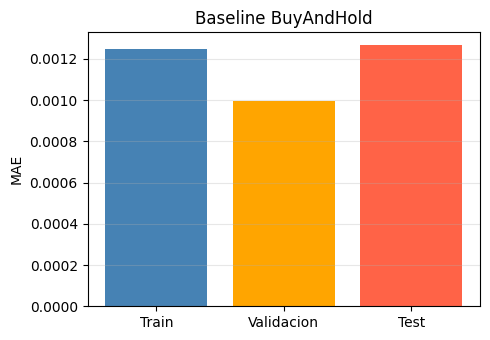

In [5]:
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
display(pd.DataFrame([resultado_bah]).set_index('modelo').round(6))
graficar_metricas_resultado(resultado_bah, 'Baseline BuyAndHold')


## 1.3 Modelos Dense (seis opciones)


Entrenando Dense (1/6)...


C:\Users\ORDENADOR\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


...


Epoch 59: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.



Epoch 65: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.


Epoch 65: early stopping


Restoring model weights from the end of the best epoch: 47.


{'modelo': 'Dense_v6', 'mae_train': 0.001242434156480159, 'mae_val': 0.0009836399734497814, 'mae_test': 0.0012663534883073301, 'n_params': 20791}


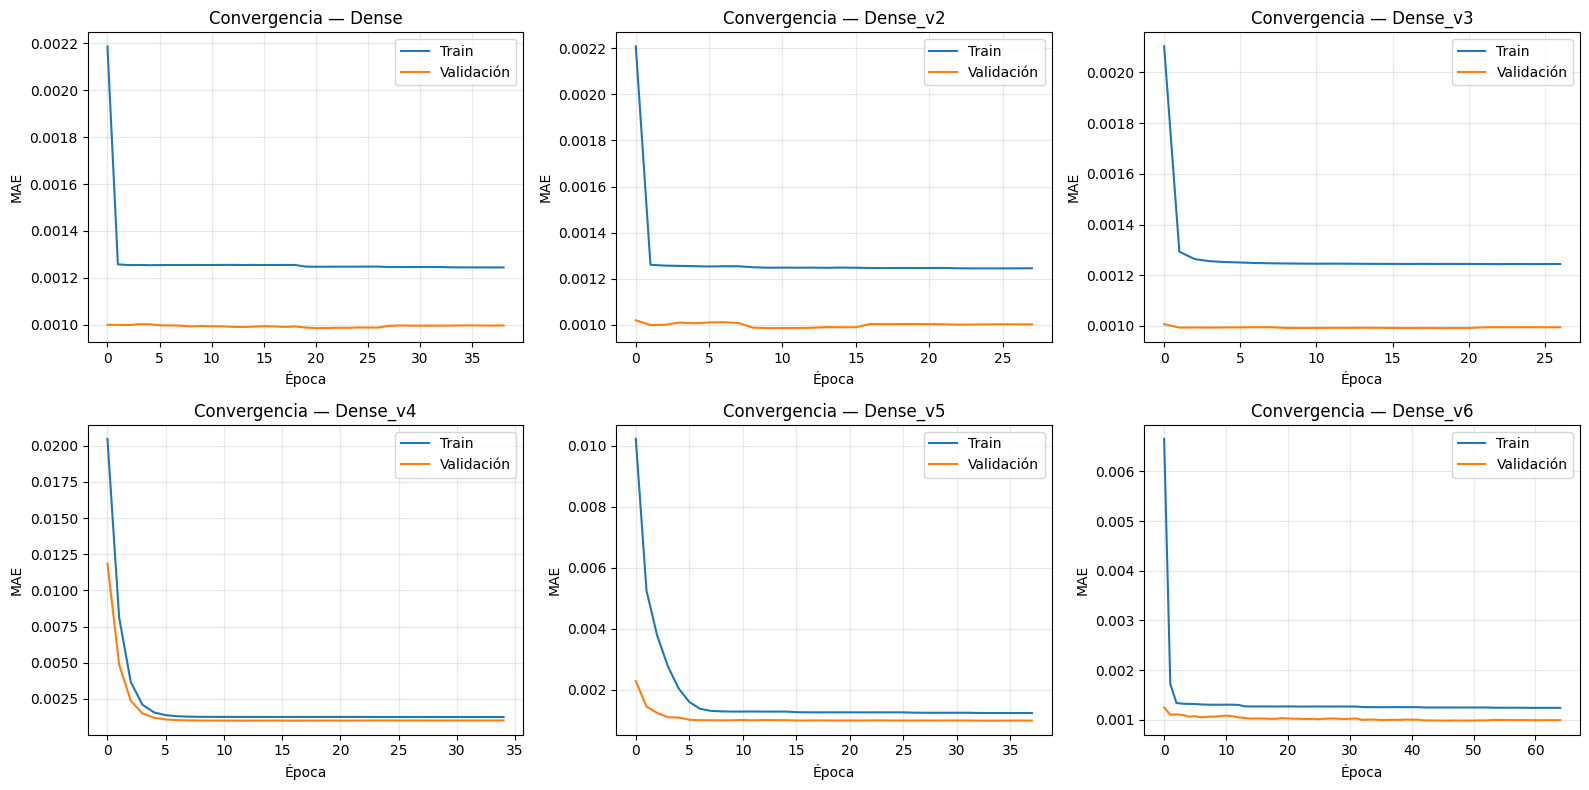

,modelo,mae_train,mae_val,mae_test,n_params
0,Dense_v6,0.001242,0.000984,0.001266,20791
1,Dense_v2,0.001246,0.000985,0.001261,40663
2,Dense,0.001246,0.000985,0.001270,94999
3,Dense_v5,0.001247,0.000991,0.001284,65047
4,Dense_v3,0.001244,0.000992,0.001269,292247
5,Dense_v4,0.001249,0.000997,0.001266,39319


In [6]:
dense_constructores = {
    'Dense': lambda: construir_dense(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v2': lambda: construir_dense_v2(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v3': lambda: construir_dense_v3(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v4': lambda: construir_dense_v4(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v5': lambda: construir_dense_v5(X_train_plano.shape[1], y_train.shape[1]),
    'Dense_v6': lambda: construir_dense_v6(X_train_plano.shape[1], y_train.shape[1]),
}

historias_dense_opciones = {}
modelos_dense_opciones = {}
resultados_dense_opciones = []

for i, (nombre, constructor) in enumerate(dense_constructores.items(), start=1):
    print(f'Entrenando {nombre} ({i}/{len(dense_constructores)})...')
    keras.backend.clear_session()
    keras.utils.set_random_seed(42 + i)
    modelo = constructor()
    hist = modelo.fit(
        X_train_plano, y_train,
        validation_data=(X_val_plano, y_val),
        epochs=120,
        batch_size=256,
        callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
        verbose=0,
    )
    resultado = evaluar_modelo(
        modelo, X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=nombre,
    )
    historias_dense_opciones[nombre] = hist
    modelos_dense_opciones[nombre] = modelo
    resultados_dense_opciones.append(resultado)
    print(resultado)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, nombre in zip(axes.ravel(), dense_constructores.keys()):
    graficar_convergencia(historias_dense_opciones[nombre], nombre, ax=ax)
plt.tight_layout()
plt.show()

df_dense_opciones = pd.DataFrame(resultados_dense_opciones).sort_values(
    ['mae_val', 'mae_test']
).reset_index(drop=True)
display(df_dense_opciones.round(6))


## 1.3.1 Mejor Dense parametrizado


Entrenando Dense_param_128_64_32 (1/3)...


C:\Users\ORDENADOR\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'mae_train': 0.0012449321782471536, 'mae_val': 0.0010022829384623466, 'mae_test': 0.0012602742175495175, 'best_train_val_gap': 8.480576798319817e-05, 'best_epoch': 199}
Entrenando Dense_param_96_48 (2/3)...


{'mae_train': 0.0012436372665259963, 'mae_val': 0.00099543432839687, 'mae_test': 0.001262036120384954, 'best_train_val_gap': 9.096029680222273e-05, 'best_epoch': 340}
Entrenando Dense_param_64_32 (3/3)...


{'mae_train': 0.0012436263364259527, 'mae_val': 0.0009945028500107497, 'mae_test': 0.0012620096238269306, 'best_train_val_gap': 9.160907939076424e-05, 'best_epoch': 230}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,Dense_param_128_64_32,0.001245,0.001002,0.001260,0.001129,0.000085,199,40663
1,Dense_param_96_48,0.001244,0.000995,0.001262,0.001132,0.000091,340,27959
2,Dense_param_64_32,0.001244,0.000995,0.001262,0.001132,0.000092,230,17623


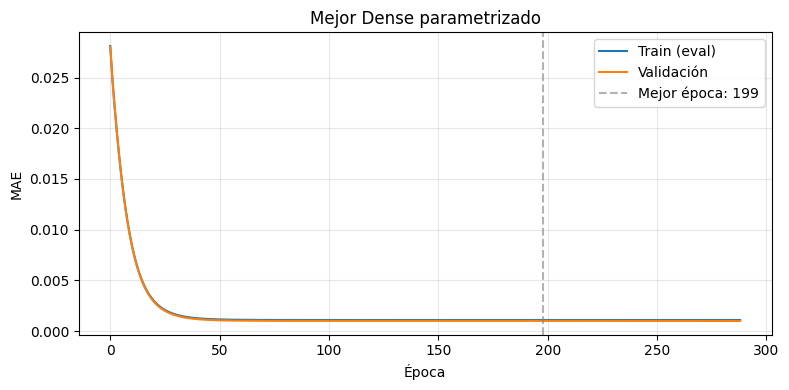

Configuracion Dense parametrizada elegida:
{'epochs': 420, 'batch_size': 512, 'lr': 0.0003, 'factor': 0.85, 'rlr_patience': 35, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 90, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 1.0, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 1.5, 'gap_excess_weight': 6.0, 'units': (128, 64, 32), 'dropout': 0.3, 'l2': 0.0001}


In [7]:
base_cfg_dense_param = {
    'epochs': 420,
    'batch_size': 512,
    'lr': 3e-4,
    'factor': 0.85,
    'rlr_patience': 35,
    'min_delta': 1e-8,
    'min_lr': 5e-7,
    'es_patience': 90,
    'restore_best_weights': True,
    'seed': 42,
    'clipnorm': 1.0,
    'verbose': 0,
    'track_train_eval': True,
    'train_eval_samples': 3000,
    'gap_metric': 'train_eval_loss',
    'es_monitor': 'balanced_score',
    'rlr_monitor': 'balanced_score',
    'gap_target': 1e-4,
    'gap_weight': 1.5,
    'gap_excess_weight': 6.0,
}

candidatos_dense_param = [
    {'nombre': 'Dense_param_128_64_32', 'units': (128, 64, 32), 'dropout': 0.30, 'l2': 1e-4, 'lr': 3e-4},
    {'nombre': 'Dense_param_96_48', 'units': (96, 48), 'dropout': 0.35, 'l2': 2e-4, 'lr': 2e-4},
    {'nombre': 'Dense_param_64_32', 'units': (64, 32), 'dropout': 0.40, 'l2': 3e-4, 'lr': 1e-4},
]

df_dense_param, hist_dense_param, modelo_dense_param, resultado_dense_param = entrenar_candidatos_parametricos(
    'construir_dense_v2_param',
    candidatos_dense_param,
    base_cfg_dense_param,
    X_train, y_train,
    X_val, y_val,
    X_train_plano, X_val_plano, X_test_plano,
)

display(df_dense_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_dense_param, 'Mejor Dense parametrizado')
print('Configuracion Dense parametrizada elegida:')
print(resultado_dense_param['cfg'])


## 1.3.2 Seleccion del mejor Dense


In [8]:
candidatos_dense_final = [(r['modelo'], r) for r in resultados_dense_opciones]
candidatos_dense_final.append((resultado_dense_param['modelo'], resultado_dense_param))
resultado_dense, df_seleccion_dense = seleccionar_mejor_familia(candidatos_dense_final, 'Dense')


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,Dense_v6,Dense,0.001242,0.000984,0.001266,20791
1,Dense_v2,Dense,0.001246,0.000985,0.001261,40663
2,Dense,Dense,0.001246,0.000985,0.001270,94999
3,Dense_v5,Dense,0.001247,0.000991,0.001284,65047
4,Dense_v3,Dense,0.001244,0.000992,0.001269,292247
5,Dense_v4,Dense,0.001249,0.000997,0.001266,39319
6,Dense_param_128_64_32,Dense,0.001245,0.001002,0.001260,40663


Resultado activo para Dense: Dense_v6


## 1.4 Modelo Recurrente (LSTM de modelos.py)


C:\Users\ORDENADOR\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 30: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 36: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


Epoch 36: early stopping


Restoring model weights from the end of the best epoch: 18.


{'modelo': 'LSTM_modelos.py', 'mae_train': 0.0012376482458487418, 'mae_val': 0.00099914874611491, 'mae_test': 0.0012735593441349894, 'n_params': 24023}


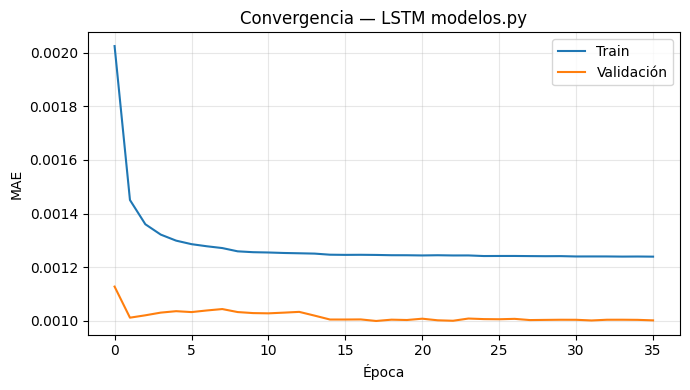

In [9]:
keras.backend.clear_session()
keras.utils.set_random_seed(142)
modelo_lstm_default = construir_recurrente(X_train.shape[1:], y_train.shape[1])
hist_lstm_default = modelo_lstm_default.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=256,
    callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
    verbose=0,
)
graficar_convergencia(hist_lstm_default, 'LSTM modelos.py')
resultado_lstm_default = evaluar_modelo(
    modelo_lstm_default, X_train, y_train,
    X_val, y_val, X_test, y_test,
    nombre='LSTM_modelos.py',
)
print(resultado_lstm_default)


## 1.4.1 Busqueda del mejor LSTM parametrizado


Entrenando LSTM_param_16_reg (1/3)...


{'mae_train': 0.0012435839468481098, 'mae_val': 0.0009964648127920635, 'mae_test': 0.0012619702687454615, 'best_train_val_gap': 9.074760600924492e-05, 'best_epoch': 520}
Entrenando LSTM_param_24_reg (2/3)...


{'mae_train': 0.0012433133322101385, 'mae_val': 0.0009976917046219148, 'mae_test': 0.0012628330703902452, 'best_train_val_gap': 8.92092939466238e-05, 'best_epoch': 520}
Entrenando LSTM_param_32_reg_fuerte (3/3)...


{'mae_train': 0.0012433507999148493, 'mae_val': 0.0009976427750664487, 'mae_test': 0.0012628555345586664, 'best_train_val_gap': 8.928054012358189e-05, 'best_epoch': 520}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,LSTM_param_16_reg,0.001244,0.000996,0.001262,0.001382,0.000091,520,2951
1,LSTM_param_24_reg,0.001243,0.000998,0.001263,0.002036,0.000089,520,5183
2,LSTM_param_32_reg_fuerte,0.001243,0.000998,0.001263,0.003440,0.000089,520,7927


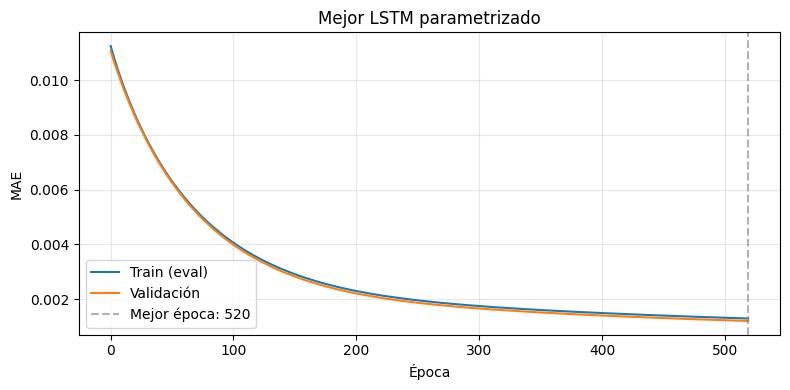

Configuracion LSTM parametrizada elegida:
{'epochs': 520, 'batch_size': 512, 'lr': 5e-05, 'factor': 0.88, 'rlr_patience': 45, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 120, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 2.0, 'gap_excess_weight': 8.0, 'recurrent_dropout': 0.0, 'units': 16, 'dropout': 0.35, 'l2': 0.0001}


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,LSTM_param_16_reg,LSTM,0.001244,0.000996,0.001262,2951
1,LSTM_modelos.py,LSTM,0.001238,0.000999,0.001274,24023


Resultado activo para LSTM: LSTM_param_16_reg


In [10]:
base_cfg_lstm = {
    'epochs': 520,
    'batch_size': 512,
    'lr': 5e-5,
    'factor': 0.88,
    'rlr_patience': 45,
    'min_delta': 1e-8,
    'min_lr': 5e-7,
    'es_patience': 120,
    'restore_best_weights': True,
    'seed': 42,
    'clipnorm': 0.5,
    'verbose': 0,
    'track_train_eval': True,
    'train_eval_samples': 3000,
    'gap_metric': 'train_eval_loss',
    'es_monitor': 'balanced_score',
    'rlr_monitor': 'balanced_score',
    'gap_target': 1e-4,
    'gap_weight': 2.0,
    'gap_excess_weight': 8.0,
    'recurrent_dropout': 0.0,
}

candidatos_lstm = [
    {'nombre': 'LSTM_param_16_reg', 'units': 16, 'dropout': 0.35, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'LSTM_param_24_reg', 'units': 24, 'dropout': 0.35, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'LSTM_param_32_reg_fuerte', 'units': 32, 'dropout': 0.45, 'l2': 2e-4, 'lr': 3e-5},
]

df_lstm_param, hist_lstm_param, modelo_lstm_param, resultado_lstm_param = entrenar_candidatos_parametricos(
    'construir_lstm_param',
    candidatos_lstm,
    base_cfg_lstm,
    X_train, y_train,
    X_val, y_val,
    X_train, X_val, X_test,
)

display(df_lstm_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_lstm_param, 'Mejor LSTM parametrizado')
print('Configuracion LSTM parametrizada elegida:')
print(resultado_lstm_param['cfg'])

resultado_lstm, df_seleccion_lstm = seleccionar_mejor_familia(
    [('LSTM_modelos.py', resultado_lstm_default), (resultado_lstm_param['modelo'], resultado_lstm_param)],
    'LSTM',
)


## 1.5 Modelo Conv1D de modelos.py


C:\Users\ORDENADOR\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 25: early stopping


Restoring model weights from the end of the best epoch: 7.


{'modelo': 'Conv1D_modelos.py', 'mae_train': 0.0012244149428125633, 'mae_val': 0.000994760757959583, 'mae_test': 0.0012982564970137203, 'n_params': 11415}


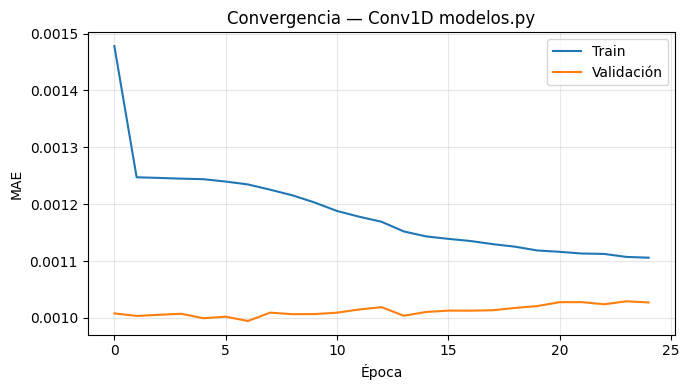

In [11]:
keras.backend.clear_session()
keras.utils.set_random_seed(242)
modelo_conv_default = construir_conv1d(X_train.shape[1:], y_train.shape[1])
hist_conv_default = modelo_conv_default.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=256,
    callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
    verbose=0,
)
graficar_convergencia(hist_conv_default, 'Conv1D modelos.py')
resultado_conv_default = evaluar_modelo(
    modelo_conv_default, X_train, y_train,
    X_val, y_val, X_test, y_test,
    nombre='Conv1D_modelos.py',
)
print(resultado_conv_default)


## 1.5.1 Busqueda del mejor Conv1D parametrizado


Entrenando Conv1D_param_16 (1/3)...


{'mae_train': 0.0012435721667477632, 'mae_val': 0.0009966780175192965, 'mae_test': 0.0012619261753934261, 'best_train_val_gap': 9.048916399478912e-05, 'best_epoch': 449}
Entrenando Conv1D_param_24 (2/3)...


{'mae_train': 0.0012433532273249325, 'mae_val': 0.0009975922698672592, 'mae_test': 0.0012629179194552473, 'best_train_val_gap': 8.932547643780708e-05, 'best_epoch': 460}
Entrenando Conv1D_param_32_k5 (3/3)...


{'mae_train': 0.0012433522826709959, 'mae_val': 0.0009976130669141076, 'mae_test': 0.0012629005992211742, 'best_train_val_gap': 8.932896889746189e-05, 'best_epoch': 460}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,Conv1D_param_16,0.001244,0.000997,0.001262,0.001178,0.000090,449,1719
1,Conv1D_param_24,0.001243,0.000998,0.001263,0.001200,0.000089,460,2855
2,Conv1D_param_32_k5,0.001243,0.000998,0.001263,0.001205,0.000089,460,6679


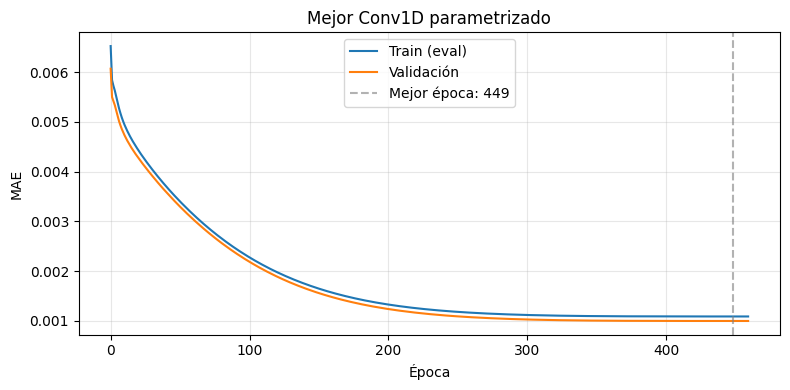

Configuracion Conv1D parametrizada elegida:
{'epochs': 460, 'batch_size': 512, 'lr': 5e-05, 'factor': 0.88, 'rlr_patience': 40, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 110, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 2.0, 'gap_excess_weight': 8.0, 'filtros': 16, 'kernel': 3, 'dropout': 0.35, 'l2': 0.0001}


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,Conv1D_modelos.py,Conv1D,0.001224,0.000995,0.001298,11415
1,Conv1D_param_16,Conv1D,0.001244,0.000997,0.001262,1719


Resultado activo para Conv1D: Conv1D_modelos.py


In [12]:
base_cfg_conv = {
    'epochs': 460,
    'batch_size': 512,
    'lr': 5e-5,
    'factor': 0.88,
    'rlr_patience': 40,
    'min_delta': 1e-8,
    'min_lr': 5e-7,
    'es_patience': 110,
    'restore_best_weights': True,
    'seed': 42,
    'clipnorm': 0.5,
    'verbose': 0,
    'track_train_eval': True,
    'train_eval_samples': 3000,
    'gap_metric': 'train_eval_loss',
    'es_monitor': 'balanced_score',
    'rlr_monitor': 'balanced_score',
    'gap_target': 1e-4,
    'gap_weight': 2.0,
    'gap_excess_weight': 8.0,
}

candidatos_conv = [
    {'nombre': 'Conv1D_param_16', 'filtros': 16, 'kernel': 3, 'dropout': 0.35, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Conv1D_param_24', 'filtros': 24, 'kernel': 3, 'dropout': 0.40, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Conv1D_param_32_k5', 'filtros': 32, 'kernel': 5, 'dropout': 0.45, 'l2': 2e-4, 'lr': 3e-5},
]

df_conv_param, hist_conv_param, modelo_conv_param, resultado_conv_param = entrenar_candidatos_parametricos(
    'construir_conv1d_param',
    candidatos_conv,
    base_cfg_conv,
    X_train, y_train,
    X_val, y_val,
    X_train, X_val, X_test,
)

display(df_conv_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_conv_param, 'Mejor Conv1D parametrizado')
print('Configuracion Conv1D parametrizada elegida:')
print(resultado_conv_param['cfg'])

resultado_conv, df_seleccion_conv = seleccionar_mejor_familia(
    [('Conv1D_modelos.py', resultado_conv_default), (resultado_conv_param['modelo'], resultado_conv_param)],
    'Conv1D',
)


## 1.6 Modelo Mixto (Conv1D + LSTM de modelos.py)



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 22: early stopping


Restoring model weights from the end of the best epoch: 4.


{'modelo': 'Mixto_modelos.py', 'mae_train': 0.0012398648496473423, 'mae_val': 0.0010172030372879524, 'mae_test': 0.0012960435137919606, 'n_params': 38999}


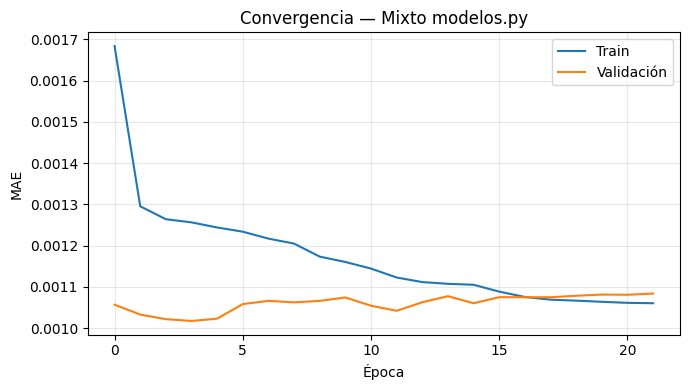

In [13]:
keras.backend.clear_session()
keras.utils.set_random_seed(342)
modelo_mixto_default = construir_mixto(X_train.shape[1:], y_train.shape[1])
hist_mixto_default = modelo_mixto_default.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=256,
    callbacks=crear_callbacks_base(patience=18, rlr_patience=6),
    verbose=0,
)
graficar_convergencia(hist_mixto_default, 'Mixto modelos.py')
resultado_mixto_default = evaluar_modelo(
    modelo_mixto_default, X_train, y_train,
    X_val, y_val, X_test, y_test,
    nombre='Mixto_modelos.py',
)
print(resultado_mixto_default)


## 1.6.1 Busqueda del mejor Mixto parametrizado


Entrenando Mixto_param_16_12 (1/3)...


{'mae_train': 0.0012435742115765541, 'mae_val': 0.0009965427508527584, 'mae_test': 0.0012619059521733892, 'best_train_val_gap': 9.063188917934895e-05, 'best_epoch': 540}
Entrenando Mixto_param_24_16 (2/3)...


{'mae_train': 0.0012433491687458872, 'mae_val': 0.000997525113905077, 'mae_test': 0.0012629119495942156, 'best_train_val_gap': 8.937646634876728e-05, 'best_epoch': 540}
Entrenando Mixto_param_24_12_k5 (3/3)...


{'mae_train': 0.001243350984818101, 'mae_val': 0.0009974969946791156, 'mae_test': 0.001262917274511987, 'best_train_val_gap': 8.936901576817036e-05, 'best_epoch': 540}


,modelo,mae_train,mae_val,mae_test,balanced_score,best_train_val_gap,best_epoch,n_params
0,Mixto_param_16_12,0.001244,0.000997,0.001262,0.001310,0.000091,540,2811
1,Mixto_param_24_16,0.001243,0.000998,0.001263,0.001727,0.000089,540,4695
2,Mixto_param_24_12_k5,0.001243,0.000997,0.001263,0.002000,0.000089,540,4859


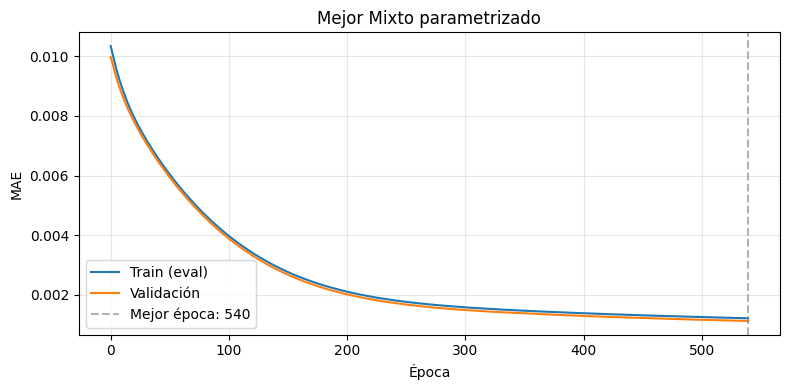

Configuracion Mixto parametrizada elegida:
{'epochs': 540, 'batch_size': 512, 'lr': 5e-05, 'factor': 0.88, 'rlr_patience': 45, 'min_delta': 1e-08, 'min_lr': 5e-07, 'es_patience': 120, 'restore_best_weights': True, 'seed': 42, 'clipnorm': 0.5, 'verbose': 0, 'track_train_eval': True, 'train_eval_samples': 3000, 'gap_metric': 'train_eval_loss', 'es_monitor': 'balanced_score', 'rlr_monitor': 'balanced_score', 'gap_target': 0.0001, 'gap_weight': 2.0, 'gap_excess_weight': 8.0, 'filtros': 16, 'lstm_units': 12, 'kernel': 3, 'dropout': 0.35, 'l2': 0.0001}


,origen,modelo,mae_train,mae_val,mae_test,n_params
0,Mixto_param_16_12,Mixto,0.001244,0.000997,0.001262,2811
1,Mixto_modelos.py,Mixto,0.001240,0.001017,0.001296,38999


Resultado activo para Mixto: Mixto_param_16_12


In [14]:
base_cfg_mixto = {
    'epochs': 540,
    'batch_size': 512,
    'lr': 5e-5,
    'factor': 0.88,
    'rlr_patience': 45,
    'min_delta': 1e-8,
    'min_lr': 5e-7,
    'es_patience': 120,
    'restore_best_weights': True,
    'seed': 42,
    'clipnorm': 0.5,
    'verbose': 0,
    'track_train_eval': True,
    'train_eval_samples': 3000,
    'gap_metric': 'train_eval_loss',
    'es_monitor': 'balanced_score',
    'rlr_monitor': 'balanced_score',
    'gap_target': 1e-4,
    'gap_weight': 2.0,
    'gap_excess_weight': 8.0,
}

candidatos_mixto = [
    {'nombre': 'Mixto_param_16_12', 'filtros': 16, 'lstm_units': 12, 'kernel': 3, 'dropout': 0.35, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Mixto_param_24_16', 'filtros': 24, 'lstm_units': 16, 'kernel': 3, 'dropout': 0.40, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Mixto_param_24_12_k5', 'filtros': 24, 'lstm_units': 12, 'kernel': 5, 'dropout': 0.45, 'l2': 2e-4, 'lr': 3e-5},
]

df_mixto_param, hist_mixto_param, modelo_mixto_param, resultado_mixto_param = entrenar_candidatos_parametricos(
    'construir_mixto_param',
    candidatos_mixto,
    base_cfg_mixto,
    X_train, y_train,
    X_val, y_val,
    X_train, X_val, X_test,
)

display(df_mixto_param[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'balanced_score', 'best_train_val_gap', 'best_epoch', 'n_params'
]].round(6))
plot_best_history(hist_mixto_param, 'Mejor Mixto parametrizado')
print('Configuracion Mixto parametrizada elegida:')
print(resultado_mixto_param['cfg'])

resultado_mixto, df_seleccion_mixto = seleccionar_mejor_familia(
    [('Mixto_modelos.py', resultado_mixto_default), (resultado_mixto_param['modelo'], resultado_mixto_param)],
    'Mixto',
)


## 1.7 Resumen de competicion y guardado


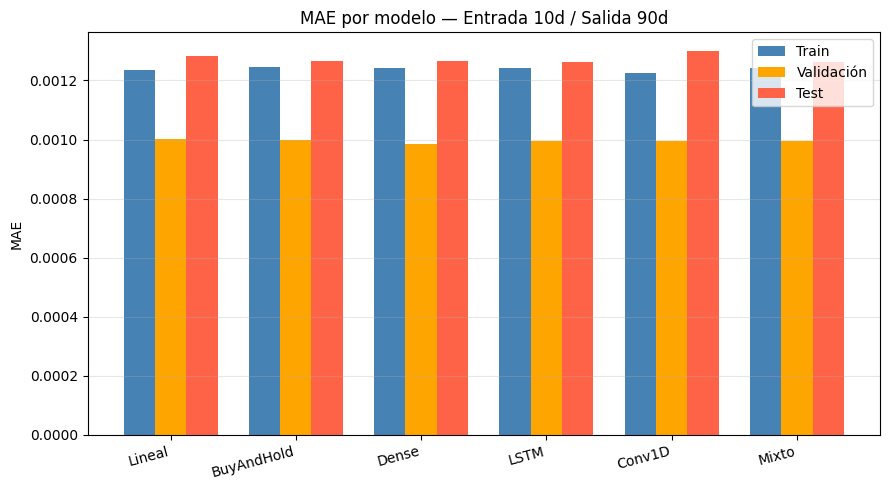

Resultados [competicion] guardados en: ../resultados/metricas/ent10_sal90.json


,mae_train,mae_val,mae_test,n_params
modelo,,,,
Lineal,0.001237,0.001003,0.001282,0
BuyAndHold,0.001246,0.000998,0.001265,0
Dense,0.001242,0.000984,0.001266,20791
LSTM,0.001244,0.000996,0.001262,2951
Conv1D,0.001224,0.000995,0.001298,11415
Mixto,0.001244,0.000997,0.001262,2811


In [15]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [16]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


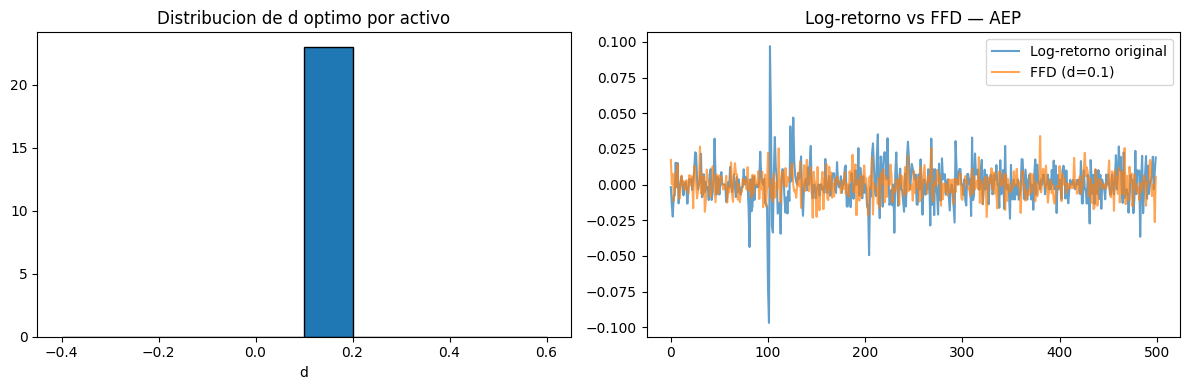

In [17]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [18]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


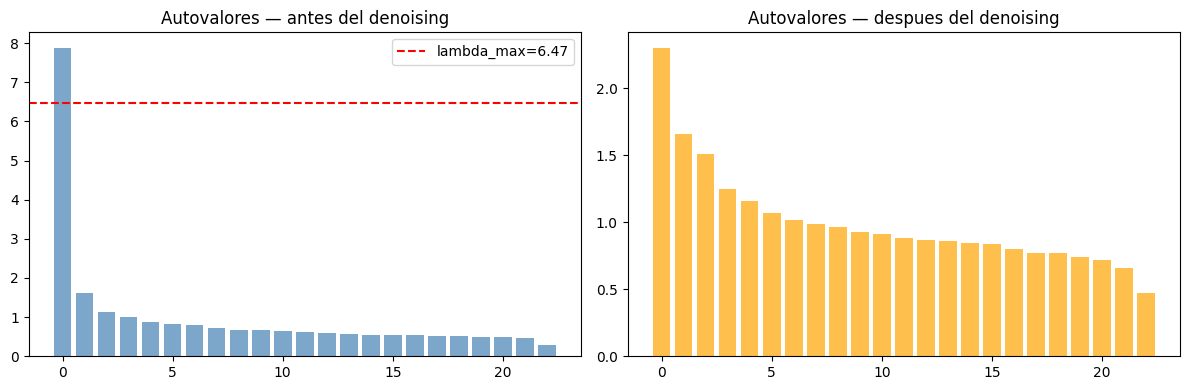

In [19]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [20]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)


Train: (13330, 10, 23)  Val: (702, 10, 23)  Test: (1560, 10, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Mixto
Epoch 1/100


  1/209 ━━━━━━━━━━━━━━━━━━━━ 6:54 2s/step - loss: 0.1774

 10/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1405 

 19/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1257

 28/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1165

...


Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0383 - val_loss: 0.0469 - learning_rate: 2.5000e-04


Epoch 21: early stopping


Restoring model weights from the end of the best epoch: 3.


{'modelo': 'Mixto_prep', 'mae_train': 0.047122603917247874, 'mae_val': 0.04310023546176209, 'mae_test': 0.05240323368774033, 'n_params': 38999}


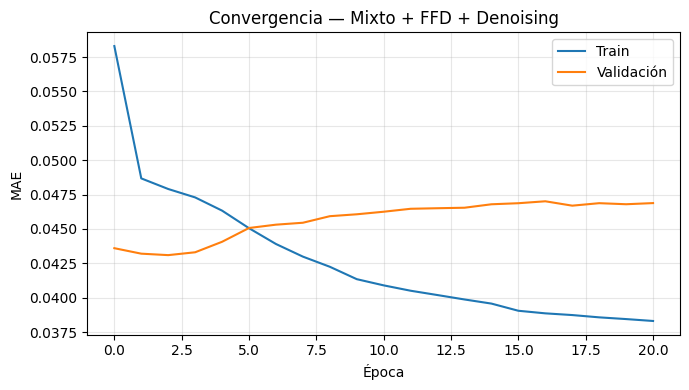

In [21]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Mixto,0.001244,0.000997,0.001262,2811
Mixto_prep,0.047123,0.043100,0.052403,38999


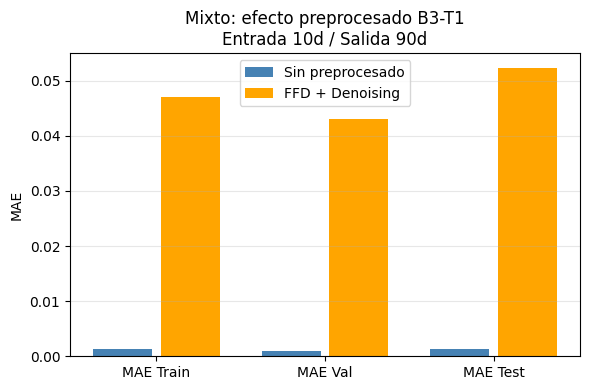

Variacion MAE test con preprocesado: -4052.7%
Resultados [investigacion] guardados en: ../resultados/metricas/ent10_sal90.json


In [22]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
